# Close evaluation of the two-sphere off-diagonal blocks $-A_{12}$, $-A_{21}$

The off-diagonal blocks of the two-sphere system in `2spheres_spherical.ipynb` are
Galerkin projections of the double-layer potential of one sphere evaluated at points on
the other sphere,
$$(A_{21})_{mn} \propto \big\langle \tilde P_m,\; \mathcal D_2[\tilde P_n]\big\rangle_{B_1},
\qquad \tilde P_n(\cos\theta) = \sqrt{\tfrac{2n+1}{4\pi}} P_n(\cos\theta) = Y_n^0 .$$
When the gap $\epsilon$ between the spheres is small, the evaluation points on $B_1$ facing
$B_2$ are **close** to the integration surface $B_2$ — precisely the close-evaluation problem.

`offdiag_bie.py` assembles these blocks with the techniques of
`sound_hard_bie.py` / `density_bie.py` (Carvalho–Khatri–Kim):
the quadrature grid on the source sphere is **rotated** so its north pole sits at the point
$y^*$ closest to the target $x$, and the plane wave
$\tilde P_n(y^*)\,e^{-ik\nu^*\cdot(x-y)}$ is **subtracted** from the density, its double-layer
contribution restored via Green's identity
$\mathcal D[e^{-ik\nu^*\cdot(x-\cdot)}](x) = \mathcal S[ik\,\nu\!\cdot\!\nu^*e^{-ik\nu^*\cdot(x-\cdot)}](x)$.

For **spheres** the exact answer is known (multipole identity)
$$\mathcal D[\tilde P_n](x) = i k^2 a^2\, j_n'(ka)\, h_n^{(1)}(k|x-C|)\, \tilde P_n(\cos\gamma),$$
which we use as ground truth — so this notebook validates the quadrature technique that will
be needed for geometries where no such identity exists.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from offdiag_bie import (SphereQuadrature, dlp_column_exact, dlp_column_naive,
                         dlp_column_rotated, dlp_column_subtract, coupling_block)

k = 2.0
a1 = a2 = 1.0
C1 = np.array([0.0, 0.0, 0.0])
quad = SphereQuadrature(24)
gaps = np.array([1e-10, 1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])

## 1. Pointwise evaluation of the coupling $\mathcal D_2[\tilde P_n](x)$

Target: the point of $B_1$ **closest** to $B_2$ (the worst case). Three quadratures:

* **naive PGQ** — unrotated grid, $\theta = \arccos\mu$, plain Gauss–Legendre weights;
* **CKK rotated** — the Carvalho–Khatri–Kim quadrature: grid rotated so its north pole is
  at $y^*$, polar angle via the **linear map** $s = \tfrac{\pi}{2}(\mu+1)$ (not $\arccos\mu$),
  explicit spherical Jacobian $\sin(s)$ in the integrand — but **no** subtraction;
* **CKK + subtraction** — the same quadrature with the plane-wave subtraction.

The rotated grid alone already gains several digits at moderate gaps (its nodes cluster in
angle near the peak of the kernel), but still stalls at $O(1)$ as $\epsilon \to 0$: the
near-singularity is only removed by the subtraction, which is $O(\epsilon)$ down to
machine precision.

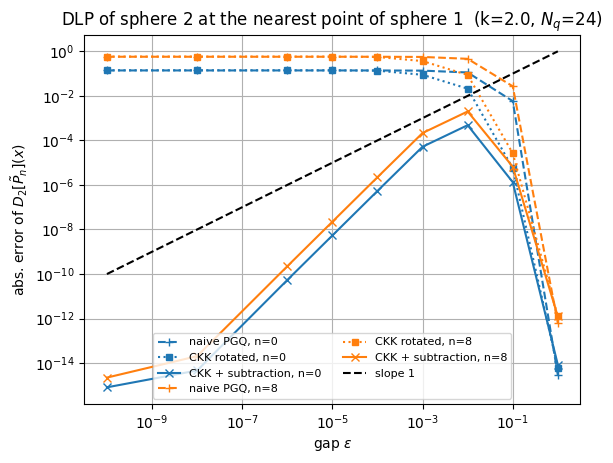

In [2]:
ns = [0, 8]
N = max(ns) + 1
err_na = np.zeros((len(gaps), len(ns)))
err_ro = np.zeros((len(gaps), len(ns)))
err_su = np.zeros((len(gaps), len(ns)))
x = np.array([0.0, 0.0, a1])                # closest point of sphere 1 to sphere 2

for i, gap in enumerate(gaps):
    C2 = np.array([0.0, 0.0, a1 + a2 + gap])
    ex = dlp_column_exact(N, k, a2, C2, x)
    err_na[i] = np.abs(dlp_column_naive(N, k, a2, C2, x, quad) - ex)[ns]
    err_ro[i] = np.abs(dlp_column_rotated(N, k, a2, C2, x, quad) - ex)[ns]
    err_su[i] = np.abs(dlp_column_subtract(N, k, a2, C2, x, quad) - ex)[ns]

plt.figure()
for j, n in enumerate(ns):
    plt.loglog(gaps, err_na[:, j], '+--', color=f'C{j}', label=f'naive PGQ, n={n}')
    plt.loglog(gaps, err_ro[:, j], 's:', color=f'C{j}', ms=4, label=f'CKK rotated, n={n}')
    plt.loglog(gaps, err_su[:, j], 'x-', color=f'C{j}', label=f'CKK + subtraction, n={n}')
plt.loglog(gaps, gaps, 'k--', label='slope 1')
plt.xlabel('gap $\\epsilon$'); plt.ylabel('abs. error of $D_2[\\tilde P_n](x)$')
plt.title(f'DLP of sphere 2 at the nearest point of sphere 1  (k={k}, $N_q$={quad.Nq})')
plt.legend(ncol=2, fontsize=8); plt.grid(True)

## 2. The assembled Galerkin block

Full block $\langle \tilde P_m, \mathcal D_2[\tilde P_n]\rangle_{B_1}$ (all Gauss–Legendre
nodes on $B_1$, incl. the far side): max entrywise error vs gap. The subtraction method's
small-gap floor is set by the **target-side projection** quadrature (the coupling function
peaks near the gap) and converges as $N_q$ grows — shown in the second panel.

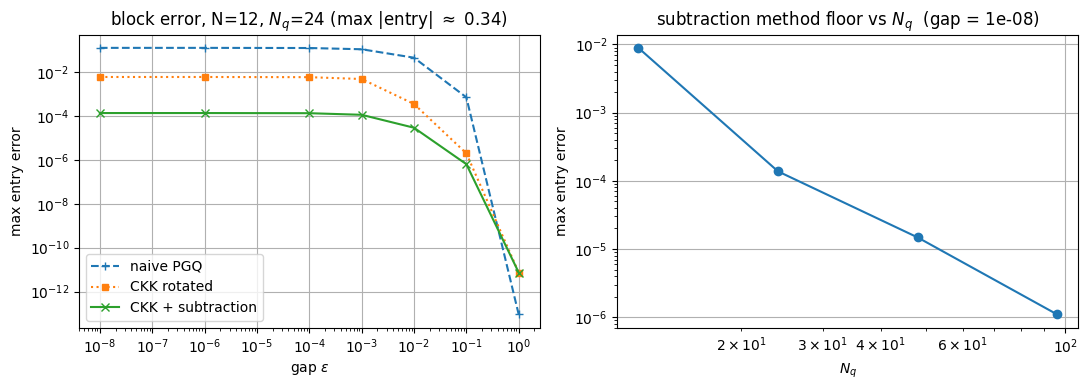

In [3]:
N = 12
block_gaps = np.array([1e-8, 1e-6, 1e-4, 1e-3, 1e-2, 1e-1, 1.0])
e_na, e_ro, e_su, scale = [], [], [], []
for gap in block_gaps:
    C2 = np.array([0.0, 0.0, a1 + a2 + gap])
    ref = coupling_block(N, k, a2, C2, a1, C1, quad, 'exact')
    e_na.append(np.abs(coupling_block(N, k, a2, C2, a1, C1, quad, 'naive') - ref).max())
    e_ro.append(np.abs(coupling_block(N, k, a2, C2, a1, C1, quad, 'rotated') - ref).max())
    e_su.append(np.abs(coupling_block(N, k, a2, C2, a1, C1, quad, 'subtract') - ref).max())
    scale.append(np.abs(ref).max())

Nqs = [12, 24, 48, 96]
gap0 = 1e-8
C2 = np.array([0.0, 0.0, a1 + a2 + gap0])
floor = []
for Nq in Nqs:
    q = SphereQuadrature(Nq)
    ref = coupling_block(N, k, a2, C2, a1, C1, q, 'exact')
    floor.append(np.abs(coupling_block(N, k, a2, C2, a1, C1, q, 'subtract') - ref).max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.loglog(block_gaps, e_na, '+--', label='naive PGQ')
ax1.loglog(block_gaps, e_ro, 's:', ms=4, label='CKK rotated')
ax1.loglog(block_gaps, e_su, 'x-', label='CKK + subtraction')
ax1.set_xlabel('gap $\\epsilon$'); ax1.set_ylabel('max entry error')
ax1.set_title(f'block error, N={N}, $N_q$={quad.Nq} (max |entry| $\\approx$ {scale[0]:.2f})')
ax1.legend(); ax1.grid(True)
ax2.loglog(Nqs, floor, 'o-')
ax2.set_xlabel('$N_q$'); ax2.set_ylabel('max entry error')
ax2.set_title(f'subtraction method floor vs $N_q$  (gap = {gap0:.0e})')
ax2.grid(True)
fig.tight_layout()

## 3. Using this in `2spheres_spherical.ipynb`

`coupling_block` reproduces the notebook's analytically-built blocks **exactly** (verified to
machine precision): with `mine = coupling_block(N, k, a1, C1, a2, C2, quad, method)`,

```python
A12_notebook[m, n] = mine[m, n] / (a2**2 * np.sqrt((2*n+1) / (4*np.pi)))
```

(the `a2**2` is the target-sphere surface measure the original notebook drops — cf. its
"all blocks have an extra a1, a2" comment — and the square root is because its columns use
raw $P_n$ while its projection rows use normalized $\tilde P_m$).

So the drop-in replacement for the near-touching regime is:

```python
quad = SphereQuadrature(Nq)
norm = np.sqrt((2*np.arange(N)+1) / (4*np.pi))
A12 = coupling_block(N, k, a1, C1, a2, C2, quad, 'subtract') / (a2**2 * norm[None, :])
A21 = coupling_block(N, k, a2, C2, a1, C1, quad, 'subtract') / (a1**2 * norm[None, :])
```

For spheres the analytic entries are already exact, so this mainly validates the machinery;
its purpose is (a) resolving the **projection** side accurately by choosing $N_q \gg N$
independently of the basis size, and (b) extending to geometries where no multipole identity
exists — `ComputeSurface` already carries the hooks (radius function `R`, semiaxes `A,B,C`)
for non-spherical shapes.